# Hidden Markov models: simulate, fit, decode

One pass through the repository's hidden Markov instance. The same
`snakes_and_ladders.opt.fit` that fits a Potts coupling in `potts_chain.ipynb` and branch
lengths in `phylo_tree.ipynb` fits the transition and emission matrices here,
unchanged — which is the claim the three notebooks exist to demonstrate
jointly.

**Scope.** Neither Viterbi decoding (#175) nor iterated conditional modes
(#176) is built. §5 therefore decodes by exhaustive enumeration, which is the
oracle those algorithms would be pinned against, and §6 has no learned policy
to report. Further Work at the end states what changes when they land.

In [1]:
import itertools
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from snakes_and_ladders.opt.fit import constrained_standard_errors, covers, fit
from snakes_and_ladders.opt.hmm import (
    HmmObjective,
    align_states,
    baum_welch,
    forward_log_likelihood,
)
from snakes_and_ladders.sim.hmm import load_hmm_params, simulate_sequences

# Resolve the repository root from wherever the notebook is opened.
REPOSITORY = next(
    parent
    for parent in [Path.cwd(), *Path.cwd().parents]
    if (parent / "pyproject.toml").is_file()
)
FIXTURE = REPOSITORY / "tests/regression/fixtures/hmm_params.yaml"

params = load_hmm_params(FIXTURE)
print(f"hidden states {params.n_states}, symbols {params.n_symbols}")
print(
    f"{params.n_sequences} sequences of length {params.sequence_length}, "
    f"seed {params.seed}"
)
print(f"\ninitial    {np.round(params.initial, 3)}")
print(f"transition\n{np.round(params.transition, 3)}")
print(f"emission\n{np.round(params.emission, 3)}")

hidden states 3, symbols 4
600 sequences of length 15, seed 20260903

initial    [0.5 0.3 0.2]
transition
[[0.7  0.2  0.1 ]
 [0.15 0.75 0.1 ]
 [0.2  0.2  0.6 ]]
emission
[[0.7  0.15 0.1  0.05]
 [0.05 0.65 0.2  0.1 ]
 [0.1  0.1  0.25 0.55]]


## 1. Simulated observations from a declared truth

The fixture states `(pi, A, B)`; the simulator walks the chain and emits under
a seeded generator. The emission rows are deliberately well separated: a
near-uniform emission makes the hidden states nearly exchangeable, and a
recovery test on an almost-unidentifiable model measures the fixture rather
than the optimizer.

In [2]:
dataset = simulate_sequences(params)
observations = dataset.observations
print(f"observations {observations.shape}  (sequences x positions)")
print("first three sequences, over the hidden paths that emitted them:")
for states, symbols in zip(dataset.states[:3], observations[:3], strict=True):
    print(f"  states  {states.tolist()}")
    print(f"  symbols {symbols.tolist()}")

log_initial = torch.log(torch.as_tensor(params.initial))
log_transition = torch.log(torch.as_tensor(params.transition))
log_emission = torch.log(torch.as_tensor(params.emission))
at_truth = float(
    forward_log_likelihood(observations, log_initial, log_transition, log_emission)
)
print(f"\nlog-likelihood of the data at the generating parameters: {at_truth:.4f}")

observations (600, 15)  (sequences x positions)
first three sequences, over the hidden paths that emitted them:
  states  [0, 0, 0, 0, 0, 2, 0, 1, 1, 1, 1, 1, 0, 1, 0]
  symbols [0, 0, 0, 0, 0, 2, 1, 2, 1, 1, 1, 1, 2, 1, 1]
  states  [0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 2, 0, 1, 1]
  symbols [0, 0, 0, 1, 3, 1, 1, 1, 1, 3, 1, 3, 0, 1, 1]
  states  [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 2]
  symbols [0, 1, 1, 2, 1, 3, 2, 3, 2, 1, 3, 1, 1, 1, 2]

log-likelihood of the data at the generating parameters: -11678.1596


## 2. The forward recursion, against brute-force path enumeration

The forward recursion marginalizes the hidden path in `O(L m^2)` per
sequence. The oracle sums over every path explicitly at `m**L`, sharing no
code with it. The check runs at `L = 8` on a handful of sequences, because
`3**8 = 6561` paths per sequence is what makes it affordable at all.

In [3]:
CHECK_LENGTH, CHECK_SEQUENCES = 8, 5

short = observations[:CHECK_SEQUENCES, :CHECK_LENGTH]
paths = list(itertools.product(range(params.n_states), repeat=CHECK_LENGTH))


def path_log_probability(path, sequence):
    """Joint log-probability of one hidden path and one observed sequence."""
    total = float(log_initial[path[0]] + log_emission[path[0], sequence[0]])
    steps = zip(path[:-1], path[1:], sequence[1:], strict=True)
    for previous, state, symbol in steps:
        total += float(log_transition[previous, state] + log_emission[state, symbol])
    return total


enumerated = sum(
    float(
        torch.logsumexp(
            torch.tensor(
                [path_log_probability(path, sequence) for path in paths],
                dtype=torch.float64,
            ),
            dim=0,
        )
    )
    for sequence in short
)
recursion = float(
    forward_log_likelihood(short, log_initial, log_transition, log_emission)
)
print(f"{len(paths)} paths per sequence, {CHECK_SEQUENCES} sequences")
print(f"forward recursion:      {recursion:.10f}")
print(f"enumerated over paths:  {enumerated:.10f}")
print(f"relative deviation {abs((recursion - enumerated) / enumerated):.2e}")

6561 paths per sequence, 5 sequences
forward recursion:      -50.1749201828
enumerated over paths:  -50.1749201828
relative deviation 0.00e+00


## 3. Fitting `(pi, A, B)` by autodiff

The likelihood is invariant to relabelling the hidden states, so a fitted
model is compared to the truth only after aligning that permutation. An
unaligned comparison shows a correct fit as a failure.

In [4]:
objective = HmmObjective(observations, params.n_states, params.n_symbols)
GRADIENT_TOLERANCE = 1e-8
result = fit(objective, gradient_tolerance=GRADIENT_TOLERANCE)
estimate = objective.constrain(result.theta)
error = constrained_standard_errors(objective, result.theta)
order = list(align_states(estimate["log_emission"], torch.as_tensor(params.emission)))

# The residual gradient norm is *not* printed. It is a near-zero number
# whose value is floating-point noise -- it moved from 6.5e-10 to 1.7e-10
# between two machines running this same cell, while every fitted
# parameter agreed to four decimals. `docs/CLAUDE.md` forbids the same
# thing in a generated caption for the same reason. What carries
# information is that the norm cleared the tolerance, so that is printed.
print(
    f"converged: {result.converged}, {result.iterations} L-BFGS steps, "
    f"relative gradient norm below {GRADIENT_TOLERANCE:.0e}"
)
# `fit` minimizes, so the objective is the negative log-likelihood.
print(
    f"maximized log-likelihood {-result.value:.4f}  "
    f"(at the generating parameters {at_truth:.4f})"
)
print(f"hidden-state alignment to truth: {order}")

covered, total = 0, 0
for name, true_value in (
    ("log_initial", params.initial),
    ("log_transition", params.transition),
    ("log_emission", params.emission),
):
    point, spread = estimate[name], error[name]
    if name == "log_transition":
        point, spread = point[order][:, order], spread[order][:, order]
    else:
        point, spread = point[order], spread[order]
    hits = covers(point, spread, torch.log(torch.as_tensor(true_value)))
    covered += int(hits.sum())
    total += hits.numel()
    print(f"\n{name.removeprefix('log_')} fitted (probabilities):")
    print(np.round(torch.exp(point).numpy(), 3))
    print(f"  truth:\n{np.round(np.asarray(true_value), 3)}")
    print(f"  {int(hits.sum())} of {hits.numel()} 95% intervals cover")

print(f"\n{covered} of {total} intervals cover their truth overall")

converged: True, 3 L-BFGS steps, relative gradient norm below 1e-08
maximized log-likelihood -11671.8114  (at the generating parameters -11678.1596)
hidden-state alignment to truth: [2, 0, 1]

initial fitted (probabilities):
[0.413 0.26  0.327]
  truth:
[0.5 0.3 0.2]
  2 of 3 95% intervals cover

transition fitted (probabilities):
[[0.693 0.186 0.121]
 [0.114 0.738 0.148]
 [0.17  0.2   0.63 ]]
  truth:
[[0.7  0.2  0.1 ]
 [0.15 0.75 0.1 ]
 [0.2  0.2  0.6 ]]
  9 of 9 95% intervals cover

emission fitted (probabilities):
[[0.721 0.152 0.096 0.031]
 [0.064 0.662 0.2   0.073]
 [0.14  0.15  0.24  0.47 ]]
  truth:
[[0.7  0.15 0.1  0.05]
 [0.05 0.65 0.2  0.1 ]
 [0.1  0.1  0.25 0.55]]
  12 of 12 95% intervals cover

23 of 24 intervals cover their truth overall


The intervals are Wald intervals from the observed information, propagated
from log-probabilities to probabilities by the delta method. Coverage on one
dataset is a draw, not a rate: the nominal 0.95 is checked over independent
replicates and against sample size in
`docs/tex/figures/opt_coverage.pdf`, where the realized rate is 91/96 at 2400
sequences.

## 4. Baum-Welch, an independent algorithm on the same data

Expectation-maximization shares no optimizer, no parameterization and no
constraint map with the gradient fit above. Two routes to the same maximum is
a stronger statement than either route converging.

In [5]:
BW_ITERATIONS = 25

curve = []
for budget in range(1, BW_ITERATIONS + 1):
    *_, value = baum_welch(
        observations,
        log_initial,
        log_transition,
        log_emission,
        max_iterations=budget,
        tolerance=0.0,
    )
    curve.append(value)

*_, converged_value = baum_welch(
    observations,
    log_initial,
    log_transition,
    log_emission,
    max_iterations=500,
    tolerance=1e-9,
)
print(f"Baum-Welch, {BW_ITERATIONS} iterations:  {curve[-1]:.4f}")
print(f"Baum-Welch, run to convergence: {converged_value:.4f}")
print(f"gradient fit (L-BFGS):          {-result.value:.4f}")
print(f"difference between the two maxima: {abs(converged_value + result.value):.2e}")
print(f"at the generating parameters:   {at_truth:.4f}")
print(
    f"monotone increasing over the first {BW_ITERATIONS}: "
    f"{all(np.diff(curve) >= -1e-9)}"
)

Baum-Welch, 25 iterations:  -11672.9296
Baum-Welch, run to convergence: -11671.8120
gradient fit (L-BFGS):          -11671.8114
difference between the two maxima: 5.73e-04
at the generating parameters:   -11678.1596
monotone increasing over the first 25: True


## 5. Decoding the hidden path

Viterbi is not built (#175). What is available is the oracle Viterbi would be
pinned against: enumerate every path and take the highest-scoring one. That
costs `m**L` against Viterbi's `O(L m^2)`, which is the whole argument for
implementing it, and it is stated here as a number rather than an assertion.

In [6]:
DECODE_SEQUENCES = 20

decoded = []
for sequence in observations[:DECODE_SEQUENCES, :CHECK_LENGTH]:
    best = max(paths, key=lambda path: path_log_probability(path, sequence))
    decoded.append(best)
print(
    f"decoded {DECODE_SEQUENCES} sequences by enumeration over {len(paths)} paths each"
)
truth = dataset.states[:DECODE_SEQUENCES, :CHECK_LENGTH]
matches = np.array(
    [
        [int(state == expected) for state, expected in zip(path, row, strict=True)]
        for path, row in zip(decoded, truth, strict=True)
    ]
)
print(f"first sequence observed:   {observations[0, :CHECK_LENGTH].tolist()}")
print(f"maximum-a-posteriori path: {list(decoded[0])}")
print(f"path that generated it:    {truth[0].tolist()}")
print(f"\npositions decoded correctly: {matches.mean():.1%}")
print(f"sequences decoded exactly:   {matches.all(axis=1).mean():.1%}")
print(
    "\nenumeration cost per sequence: "
    f"{params.n_states}**{CHECK_LENGTH} = {params.n_states**CHECK_LENGTH} paths;"
)
print(
    f"Viterbi would cost {CHECK_LENGTH} * {params.n_states}**2 = "
    f"{CHECK_LENGTH * params.n_states**2} operations (#175)."
)

decoded 20 sequences by enumeration over 6561 paths each
first sequence observed:   [0, 0, 0, 0, 0, 2, 1, 2]
maximum-a-posteriori path: [0, 0, 0, 0, 0, 1, 1, 1]
path that generated it:    [0, 0, 0, 0, 0, 2, 0, 1]

positions decoded correctly: 75.0%
sequences decoded exactly:   20.0%

enumeration cost per sequence: 3**8 = 6561 paths;
Viterbi would cost 8 * 3**2 = 72 operations (#175).


## 6. Log-likelihood against discrete step

The counterpart of the episode traces in the other two notebooks. There is no
search episode here because the hidden Markov model has no discrete move set
(#176); what steps instead is Baum-Welch's iteration, and the reference line
is the same one the other notebooks use — the likelihood of the data at the
generating parameters.

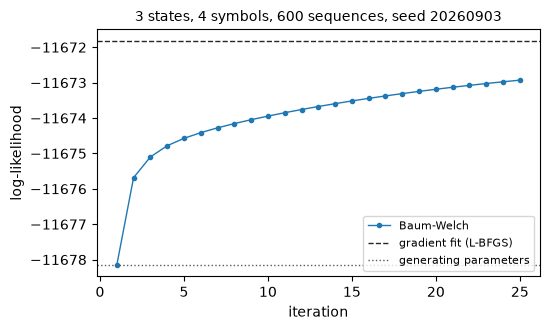

In [7]:
figure, axis = plt.subplots(figsize=(5.6, 3.4))
axis.plot(
    range(1, len(curve) + 1),
    curve,
    marker="o",
    markersize=3,
    linewidth=1.0,
    label="Baum-Welch",
)
axis.axhline(
    -result.value,
    color="0.15",
    linestyle="--",
    linewidth=1.0,
    label="gradient fit (L-BFGS)",
)
axis.axhline(
    at_truth, color="0.35", linestyle=":", linewidth=1.0, label="generating parameters"
)
axis.ticklabel_format(axis="y", useOffset=False, style="plain")
axis.set_xlabel("iteration")
axis.set_ylabel("log-likelihood")
axis.set_title(
    f"{params.n_states} states, {params.n_symbols} symbols, "
    f"{params.n_sequences} sequences, seed {params.seed}",
    fontsize=10,
)
axis.legend(fontsize=8, loc="lower right")
figure.tight_layout()
plt.show()

The fitted maximum sits above the likelihood at the generating parameters.
That is expected and not an error: the maximum-likelihood estimate maximizes
the likelihood of *this* sample, and the truth does not.

## Further work

What this notebook could not demonstrate, because the feature is not built.
Each line names the issue that carries it.

- **Viterbi decoding (#175).** §5 enumerates `3**8 = 6561` paths per sequence
  to do in exponential time what Viterbi does in `O(L m^2)`. Nothing here
  scales past `L = 10`.
- **Iterated conditional modes (#176).** No discrete move set exists over
  state paths, so there is no search episode to trace and no environment to
  train a policy in. §6 plots Baum-Welch's iterations in place of one.
- **Forward-backward as an evaluator (#173).** The forward recursion is
  exposed; the posteriors are not, so no posterior-marginal decoder can be
  compared against the maximum-a-posteriori path in §5.
- **Re-execution in CI.** This notebook is committed with its outputs, and no
  job re-runs it: Jupyter is not a dependency of this repository. Unlike the
  figures in `docs/tex/`, which CI regenerates and byte-compares on every
  pull request, these numbers date from the commit that wrote them.